In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.nn import functional as F
import os
import numpy as np
import matplotlib.pyplot as plt

In [31]:
# --- Configuration and Hyperparameters ---
EPOCHS = 10
BATCH_SIZE = 128
LEARNING_RATE = 1e-2
LATENT_DIM = 128
IMAGE_SIZE = 32
CHANNELS = 3
BETA = 1.0 # Weight for KL divergence (Beta-VAE concept, 1.0 is standard VAE)

In [32]:
# Determine the device to use (GPU if available, otherwise CPU)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [33]:
class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM,channels=CHANNELS,image_size=IMAGE_SIZE,lr=LEARNING_RATE):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.image_size = image_size
        self.lr = lr
        
        # 1. Encoder (P(z|x)) - Maps image to latent distribution parameters (mu and log_var)
        self.encoder = nn.Sequential(
            # Input: 3 x 32 x 32 (CIFAR-10)
            nn.Conv2d(channels, 32, kernel_size=4, stride=2, padding=1), # 32 x 16 x 16
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 64 x 8 x 8
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 128 x 4 x 4
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            
            # Flatten to vector
            nn.Flatten()
        )
        
        # Calculate the size after convolution (128 * 4 * 4 = 2048)
        self.flat_size = 128 * (IMAGE_SIZE // 8) * (IMAGE_SIZE // 8) # 2048 for 32x32
        
        # Latent variables layers
        self.fc_mu = nn.Linear(self.flat_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_size, latent_dim)

        # 2. Decoder (P(x|z)) - Maps latent vector to image
        self.fc_decode = nn.Linear(latent_dim, self.flat_size)
        
        self.decoder = nn.Sequential(
            # Reshape: 128 x 4 x 4
            
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # 64 x 8 x 8
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # 32 x 16 x 16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            # Output: 3 x 32 x 32 (Sigmoid activation for pixel values [0, 1])
            nn.ConvTranspose2d(32, CHANNELS, kernel_size=4, stride=2, padding=1), # 3 x 32 x 32
            nn.Sigmoid() # To output pixel values between 0 and 1
        )

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick: z = mu + std * epsilon, where epsilon ~ N(0, I)
        """
        # Calculate standard deviation (std = exp(0.5 * logvar))
        std = torch.exp(0.5 * logvar)
        # Sample epsilon from standard normal distribution
        eps = torch.randn_like(std)
        # Return the latent sample z
        return mu + eps * std

    def forward(self, x):
        # 1. Encode
        encoded = self.encoder(x)
        mu = self.fc_mu(encoded)
        logvar = self.fc_logvar(encoded)
        
        # 2. Reparameterize (sample z)
        z = self.reparameterize(mu, logvar)
        
        # 3. Decode
        decoded = self.fc_decode(z)
        # Reshape to 4x4 feature map
        decoded = decoded.view(-1, 128, IMAGE_SIZE // 8, IMAGE_SIZE // 8)
        reconstruction = self.decoder(decoded)
        
        return reconstruction, mu, logvar
    
    @torch.no_grad()
    def generate_samples(self, num_samples=1, z=None):
        """
        Generates images by decoding latent vectors.
        
        Args:
            num_samples (int): The number of images to generate (ignored if z is provided).
            z (torch.Tensor, optional): A batch of latent vectors (shape [N, LATENT_DIM]).
            If None, vectors are sampled from the standard Gaussian prior P(z).
        
        Returns:
            torch.Tensor: A batch of generated images (shape [N, C, H, W]).
        """
        
        # Use the same device as the model parameters
        model_device = next(self.parameters()).device
        
        if z is None:
            # Generate random latent vectors if none are provided
            z = torch.randn(num_samples, self.latent_dim).to(model_device)
        else:
            # Ensure the input latent vector is on the correct device
            z = z.to(model_device)
        
        # Decode the latent vector(s)
        decoded = self.fc_decode(z)
        
        # Reshape to 4x4 feature map. The first dimension is batch size
        decoded = decoded.view(-1, 128, IMAGE_SIZE // 8, IMAGE_SIZE // 8)
        
        # Pass through the convolutional decoder layers
        generated_images = self.decoder(decoded)
        
        return generated_images

    def load_weights(self, filepath):
        """
        Loads the model parameters from a PyTorch checkpoint file (.pth) or attempts to handle .npz.
        
        Args:
            filepath (str): Path to the saved model file.
        """
        model_device = next(self.parameters()).device
        
        if filepath.endswith('.pth'):
            try:
                # Load the state dictionary, mapping storage to the current device
                state_dict = torch.load(filepath, map_location=model_device)
                self.load_state_dict(state_dict)
                print(f"Successfully loaded VAE weights from {filepath} onto {model_device}.")
            except FileNotFoundError:
                print(f"Error: Checkpoint file not found at {filepath}.")
            except Exception as e:
                print(f"Error loading PyTorch state dict: {e}")
        elif filepath.endswith('.npz'):
            print("Note: Loading from a raw .npz file is non-standard for PyTorch model weights.")
            print("This requires manual loading of NumPy arrays and mapping them to PyTorch layers, which is highly specific.")
            print("Please use a PyTorch `.pth` checkpoint file for reliable parameter loading.")
        else:
            print(f"Unsupported file format for loading weights: {filepath}. Please use a .pth file.")


In [34]:
VAE_model = VAE(LATENT_DIM)

In [35]:
def vae_loss(recon_x, x, mu, logvar):
    """
    Calculates the Evidence Lower Bound (ELBO) loss.
    ELBO = Reconstruction Loss + KL Divergence Loss
    """
    # 1. Reconstruction Loss (E_q(z|x) [log P(x|z)])
    # Use Binary Cross-Entropy (BCE) for image reconstruction loss, 
    # which is common for VAEs with Sigmoid output. 
    
    # Flatten the image for BCE calculation
    BCE = F.binary_cross_entropy(recon_x.view(-1, CHANNELS * IMAGE_SIZE * IMAGE_SIZE), 
                                x.view(-1, CHANNELS * IMAGE_SIZE * IMAGE_SIZE), 
                                reduction='sum')

    # 2. KL Divergence Loss (D_KL(Q(z|x) || P(z)))
    # Analytic KL divergence between N(mu, exp(logvar)) and N(0, 1)
    # Formula: 0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    KL_Divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Total loss (Negative ELBO)
    # We use 'sum' reduction for both, so we divide by batch size for averaging
    return (BCE + BETA * KL_Divergence) / x.size(0)

In [36]:
def get_data_loaders():
    # Define transformations: Convert to tensor and normalize to [0, 1] for VAE
    transform = transforms.Compose([
        transforms.ToTensor(), # Converts image to Tensor, scales to [0.0, 1.0]
        # CIFAR-10 is 32x32. No need for resize.
    ])
    
    # Download and load the CIFAR-10 training dataset
    # train_dataset = datasets.EMNIST(
    #     root='./data', 
    #     split= "digits",
    #     train=True, 
    #     download=True, 
    #     transform=transform
    # )
    
    # # Download and load the CIFAR-10 training dataset
    train_dataset = datasets.CIFAR10(
        root='./data', 
        train=True, 
        download=True, 
        transform=transform
    )
    
    # Create the data loader
    train_loader = DataLoader(
        train_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=True, 
        num_workers=os.cpu_count() // 2 if os.cpu_count() else 0, # Use half cores for loading
        pin_memory=True
    )
    
    return train_loader

In [37]:
def train(model, data_loader, optimizer, epoch):
    model.train()
    total_loss = 0
    
    for batch_idx, (data, _) in enumerate(data_loader):
        # Move data to the specified device
        data = data.to(DEVICE)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        recon_batch, mu, logvar = model(data)
        
        # Calculate loss
        loss = vae_loss(recon_batch, data, mu, logvar)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(data_loader.dataset)} '
                  f'({100. * batch_idx / len(data_loader):.0f}%)]\tLoss: {loss.item():.6f}')
            
    avg_loss = total_loss / BATCH_SIZE
    print(f'====> Epoch: {epoch} Average loss: {avg_loss:.4f}')

In [38]:
vae_model = VAE(latent_dim=LATENT_DIM).to(DEVICE)
vae_optimizer = optim.Adam(vae_model.parameters(), lr=vae_model.lr)
cifar_loader = get_data_loaders()

Files already downloaded and verified


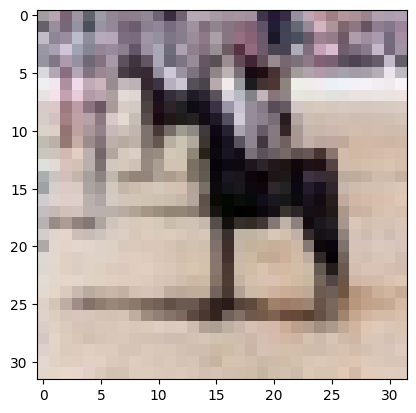

In [39]:
L = len(cifar_loader.dataset)
n = np.random.randint(0,L)
image,_ = cifar_loader.dataset[n]
transform = transforms.Compose([transforms.ToPILImage()])
image = transform(image)
plt.imshow(image,cmap="gray")

In [40]:
for epoch in range(1,EPOCHS + 1):
    train(VAE_model,cifar_loader,vae_optimizer,epoch)

Train Epoch: 1 [0/50000 (0%)]	Loss: 2280.885498
Train Epoch: 1 [12800/50000 (26%)]	Loss: 2279.272705
Train Epoch: 1 [25600/50000 (51%)]	Loss: 2279.313965
Train Epoch: 1 [38400/50000 (77%)]	Loss: 2281.296387
====> Epoch: 1 Average loss: 6972.1888
Train Epoch: 2 [0/50000 (0%)]	Loss: 2280.035156
Train Epoch: 2 [12800/50000 (26%)]	Loss: 2284.195068
Train Epoch: 2 [25600/50000 (51%)]	Loss: 2280.142578
Train Epoch: 2 [38400/50000 (77%)]	Loss: 2285.895264
====> Epoch: 2 Average loss: 6972.2757
Train Epoch: 3 [0/50000 (0%)]	Loss: 2285.116943
Train Epoch: 3 [12800/50000 (26%)]	Loss: 2284.412109
Train Epoch: 3 [25600/50000 (51%)]	Loss: 2279.231201
Train Epoch: 3 [38400/50000 (77%)]	Loss: 2282.298096
====> Epoch: 3 Average loss: 6972.3362
Train Epoch: 4 [0/50000 (0%)]	Loss: 2283.458740
Train Epoch: 4 [12800/50000 (26%)]	Loss: 2281.759033
Train Epoch: 4 [25600/50000 (51%)]	Loss: 2286.552246
Train Epoch: 4 [38400/50000 (77%)]	Loss: 2283.725098
====> Epoch: 4 Average loss: 6972.3640
Train Epoch: 5 [